In [1]:
import mne
import requests
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.io import loadmat
from mne import create_info
from mne.io import RawArray
from mne.preprocessing import ICA
from mne.datasets import fetch_fsaverage
from mne.minimum_norm import make_inverse_operator, apply_inverse_raw
from mne import read_labels_from_annot
# import bci_star
# import rpp_epochs
import matplotlib.pyplot as plt
import os
import io
import h5py

In [ ]:
# Abrir el archivo en modo lectura
with open("Z:\Proyectos\Cerebro\RECORDS.txt", "r", encoding="utf-8") as f:
    texto = f.read()
texto=texto.splitlines()

path_files=list()
for t in texto:
    path_files.append(t.split(sep="/")[1])
path_files



<>:2: SyntaxWarning: invalid escape sequence '\P'
<>:2: SyntaxWarning: invalid escape sequence '\P'
C:\Users\THIN\AppData\Local\Temp\ipykernel_24728\2046022572.py:2: SyntaxWarning: invalid escape sequence '\P'
  with open("Z:\Proyectos\Cerebro\RECORDS.txt", "r", encoding="utf-8") as f:


['0284',
 '0286',
 '0296',
 '0299',
 '0303',
 '0306',
 '0311',
 '0312',
 '0313',
 '0316',
 '0319',
 '0320',
 '0326',
 '0328',
 '0332',
 '0334',
 '0335',
 '0337',
 '0340',
 '0341',
 '0342',
 '0344',
 '0346',
 '0347',
 '0348',
 '0349',
 '0350',
 '0351',
 '0352',
 '0353',
 '0354',
 '0355',
 '0356',
 '0357',
 '0358',
 '0359',
 '0360',
 '0361',
 '0362',
 '0363',
 '0364',
 '0365',
 '0366',
 '0367',
 '0368',
 '0369',
 '0370',
 '0371',
 '0372',
 '0373',
 '0375',
 '0376',
 '0377',
 '0378',
 '0379',
 '0380',
 '0382',
 '0383',
 '0384',
 '0385',
 '0387',
 '0389',
 '0390',
 '0391',
 '0392',
 '0394',
 '0395',
 '0396',
 '0397',
 '0398',
 '0399',
 '0400',
 '0402',
 '0403',
 '0404',
 '0405',
 '0406',
 '0407',
 '0409',
 '0410',
 '0411',
 '0412',
 '0413',
 '0414',
 '0415',
 '0416',
 '0417',
 '0418',
 '0419',
 '0420',
 '0421',
 '0422',
 '0423',
 '0424',
 '0426',
 '0427',
 '0428',
 '0429',
 '0430',
 '0431',
 '0432',
 '0433',
 '0434',
 '0435',
 '0436',
 '0437',
 '0438',
 '0439',
 '0440',
 '0441',
 '0442',
 

In [ ]:
data=list()
for k, path in enumerate(path_files):
    print(k) 
    url = f"https://physionet.org/content/i-care/2.1/training/{path}/{path}.txt"  # URL del archivo
    respuesta = requests.get(url)
    a=respuesta.text.split(sep="Patient: ")[1].splitlines()[:10]
    dato=list()
    for i in a:
        b=i.split(sep=": ")
        if len(b)==1:
            dato.append(b[0])
        else:
            dato.append(b[1].split(sep="<")[0])
    data.append(tuple(dato))
data

In [86]:
df=pd.DataFrame(data,columns=["Id_Patient", "Hospital", "Age", "Sex", "ROSC", "OHCA","Shockable Rhythm","TTM", "Outcome","CPC"])
df["Id_Patient"]=df["Id_Patient"].map(int)
df["Age"]=pd.to_numeric(df["Age"],errors="coerce")
df["ROSC"]=pd.to_numeric(df["ROSC"],errors="coerce")
df["TTM"]=pd.to_numeric(df["TTM"],errors="coerce")
df["CPC"]=pd.to_numeric(df["CPC"],errors="coerce")
df.to_csv("data_patients.csv", sep=";", index=False)

In [2]:
# === STEP 1: Load .mat and .hea data ===
def load_signal_pair(mat_file, hea_file):
    # Cargar matriz desde archivo .mat
    mat = loadmat(mat_file)
    signal = mat['val']  # [n_channels, n_samples]

    # Leer archivo .hea
    with open(hea_file, 'r') as f:
        lines = f.readlines()

    header_main = lines[0].strip().split()
    num_channels = int(header_main[1])

    # Frecuencia de muestreo (fs) está en la primera línea, tercer campo
    fs = float(lines[0].split()[2])

    channel_lines = [line for line in lines[1:] if len(line.split()) >= 9]
    # Extraer nombre del canal (9º campo en cada línea válida)
    channels = [line.split()[8] for line in channel_lines]

    assert signal.shape[0] == len(channels), f"Canales en {mat_file} no coinciden con .hea"

    return {
        "signal": signal,
        "channels": channels,
        "fs": fs
    }

In [123]:
import requests

login_url = "https://physionet.org/login/"
payload = {
    "username": "juanlealc",
    "password": "t0sc0f0nd0blanc0"
}

with requests.Session() as s:
    # login
    s.post(login_url, data=payload)

    # ya con sesión, descargar el archivo
    url_mat = "https://physionet.org/static/published-projects/i-care/2.1/training/0284/0284_001_004_EEG.mat"
    resp_mat = s.get(url_mat)
    resp_mat.raise_for_status()
    
    with open("../data_prove/ECG.mat", "wb") as f:
        f.write(resp_mat.content)
    
    
    
    url_hea = "https://physionet.org/static/published-projects/i-care/2.1/training/0284/0284_001_004_EEG.hea"
    resp_hea = s.get(url_hea)
    resp_hea.raise_for_status()
    
    with open("../data_prove/ECG.hea", "wb") as f:
        f.write(resp_hea.content)

mat_path="../data_prove/ECG.mat"
hea_path="../data_prove/ECG.hea"
eeg_data = load_signal_pair(mat_path, hea_path)

In [3]:
# === Archivos ===
folder="../data_prove/"
paciente="0284"
numn_file="052"
minuto="048"
eeg_mat, eeg_hea = folder + paciente+"_"+ numn_file + "_" + minuto+ "_EEG.mat", folder + paciente+"_"+ numn_file + "_" + minuto+ "_EEG.hea"
ecg_mat, ecg_hea = folder + paciente+"_"+ numn_file + "_" + minuto+ "_ECG.mat", folder + paciente+"_"+ numn_file + "_" + minuto+ "_ECG.hea"
oth_mat, oth_hea = folder + paciente+"_"+ numn_file + "_" + minuto+ "_OTHER.mat", folder + paciente+"_"+ numn_file + "_" + minuto+ "_OTHER.hea"

# === Diccionario con todos los datos ===
data = {
    "EEG": load_signal_pair(eeg_mat, eeg_hea),
    "ECG": load_signal_pair(ecg_mat, ecg_hea),
    "OTHER": load_signal_pair(oth_mat, oth_hea)
}

eeg_data = load_signal_pair(eeg_mat, eeg_hea)
ecg_data = load_signal_pair(ecg_mat, ecg_hea)
other_data = load_signal_pair(oth_mat, oth_hea)

In [8]:
pd.DataFrame(eeg_data["signal"].T,columns=eeg_data["channels"])


,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,6432,9297,9125,11542,13806,-13617,28215,-12243,-11670,-12627,1448,13584,1279,3200,4292,-6620,11911,9475,6445
1,1564,5856,6962,10393,12975,-13039,28247,-12184,-11427,-12444,874,12368,1131,3522,4162,-6143,8116,9019,6534
2,-1135,3553,5636,9615,12438,-12414,28215,-12144,-11139,-12314,-118,12414,1019,3522,4324,-6127,5820,8704,6392
3,-2371,2414,4829,9075,11216,-11452,28054,-12208,-10977,-12484,-770,13148,871,3200,4405,-6915,4640,8109,6234
4,-5323,-309,2955,6878,10581,-10489,27990,-12216,-10634,-12587,-1057,12758,723,2778,4454,-7424,1419,7513,6172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1191495,6684,8431,10336,8162,14246,-13569,27885,-12545,-11841,-12832,5520,10762,5006,2481,6255,-6324,9009,6602,5237
1191496,3834,5707,9442,7182,14490,-14435,28086,-12518,-11826,-12765,5728,10739,5934,2828,6563,-5963,6457,6532,5317
1191497,-26,2365,7164,5391,13855,-14194,28111,-12513,-11503,-12698,4893,10464,5915,2952,7164,-6127,2854,6077,5281
1191498,-1640,1276,6270,4816,12877,-13280,27942,-12510,-11221,-12667,4136,10441,5155,2803,6693,-6291,1323,5587,5167


In [94]:
def create_raw_array(signal, channels, sfreq, group):
    eeg_names = ['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T3', 'T4', 'C3', 'C4',
                 'T5', 'T6', 'P3', 'P4', 'O1', 'O2', 'Fz', 'Cz', 'Pz', 'Fpz', 'Oz', 'F9']
    ecg_names = ['ECG', 'ECG1', 'ECG2', 'ECGL', 'ECGR']

    ch_types = []
    for ch in channels:
        if ch in eeg_names:
            ch_types.append('eeg')
        elif ch in ecg_names:
            ch_types.append('ecg')
        else:
            ch_types.append('misc')

    info = mne.create_info(ch_names=channels, sfreq=sfreq, ch_types=ch_types)

    # Solo escalar si el grupo es EEG (o si el canal es eeg)
    if all(t == 'eeg' for t in ch_types):
        raw = mne.io.RawArray(signal * 1e-6, info, verbose=False)
    else:
        raw = mne.io.RawArray(signal, info, verbose=False)

    raw.info['description'] = f'{group} data'
    return raw


In [95]:
raw_eeg = create_raw_array(
    eeg_data['signal'], eeg_data['channels'], eeg_data['fs'], 'EEG'
)

raw_ecg = create_raw_array(
    ecg_data['signal'], ecg_data['channels'], ecg_data['fs'], 'ECG'
)

raw_other = create_raw_array(
    other_data['signal'], other_data['channels'], other_data['fs'], 'OTHER'
)

In [96]:
raw_eeg

<RawArray | 19 x 1191500 (2383.0 s), ~172.7 MiB, data loaded>

In [32]:
def signal_by_channels(raw_signal, filename):
    # Obtener datos y nombres de los canales
    data, times = raw_signal[:]
    channel_names = raw_signal.ch_names

    # Graficar cada canal individualmente
    fig, axs = plt.subplots(len(channel_names), 1, figsize=(10, len(channel_names) * 2), sharex=True)

    for i, ax in enumerate(axs):
        ax.plot(times, data[i] * 1e6)  # Convertir a microvoltios (μV)
        ax.set_ylabel(channel_names[i])
        ax.set_xlim([times[0], times[-1]])

    plt.xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.savefig(filename)  # Guardar la figura como archivo
    plt.close(fig)  # Cerrar la figura para liberar memoria
    

In [10]:
# Graficar raw signal de EEG por canales
signal_by_channels(raw_eeg, "../Image/raw_eeg_plot.png")

In [16]:
# Filtrar
# --- 1. Asignar montaje estándar al EEG ---
montage = mne.channels.make_standard_montage('standard_1020')
raw_eeg.set_montage(montage)

filtered_signal_eeg = raw_eeg.copy().filter(l_freq=1., h_freq=40., picks='eeg')
raw_ecg_filtrado = raw_ecg.copy().filter(l_freq=1., h_freq=40., picks='ecg')

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

No data channels found. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge:

In [10]:
eeg_data["signal"].shape

(19, 1191500)

4 duplicate electrode labels found:
T7/T3, T8/T4, P7/T5, P8/T6
Plotting 90 unique labels.


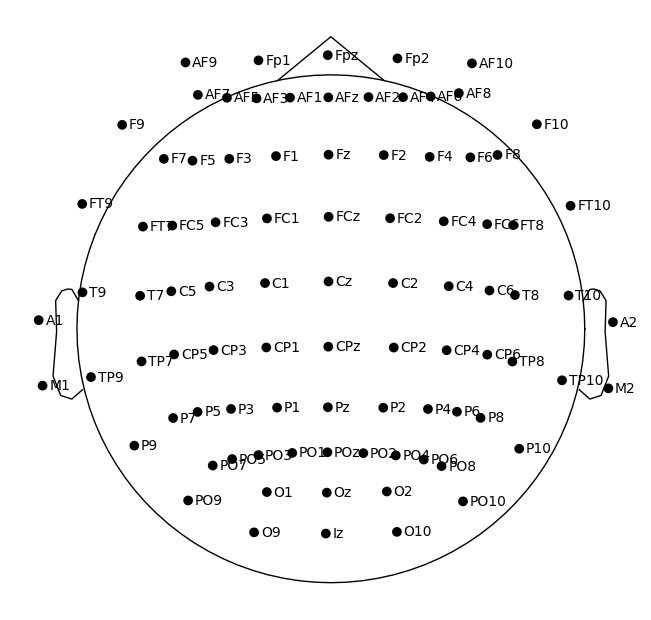

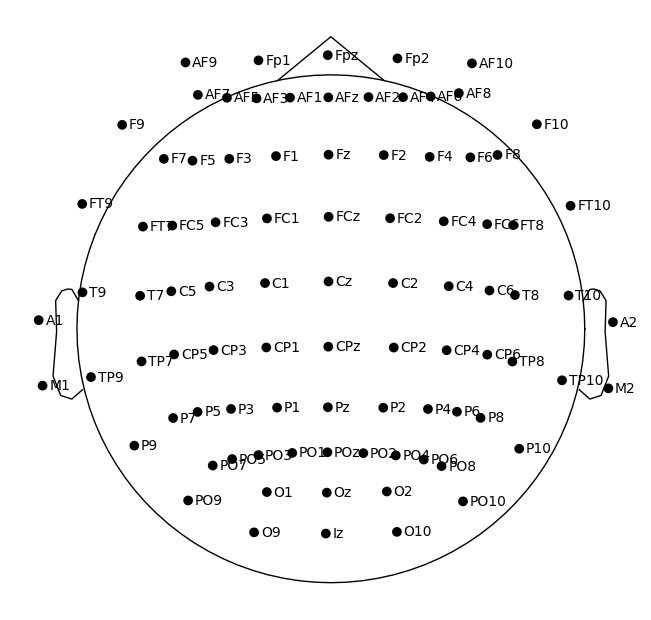

In [17]:
montage.plot()

Using channel ECG to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 5000 samples (10.000 s)

Number of ECG events detected : 2704 (average pulse 68.08224926563156 / min.)
Not setting metadata
2704 matching events found
No baseline correction applied
Using data from preloaded Raw for 2704 events and 501 original time points ...
0 bad epochs dropped
Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


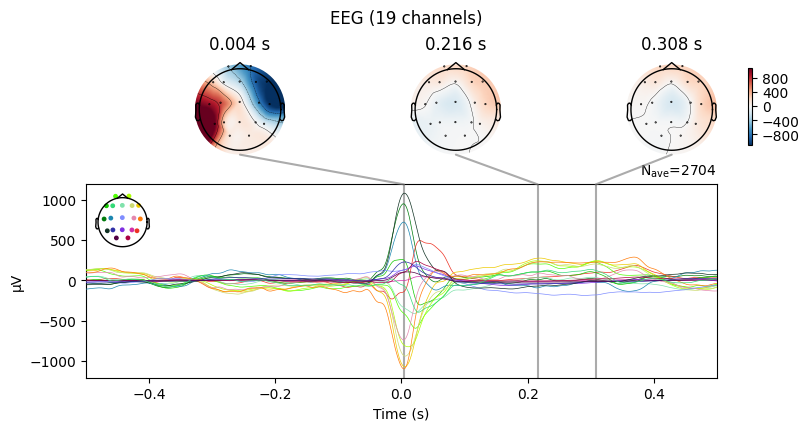

Fitting ICA to data using 19 channels (please be patient, this may take a while)
Selecting by explained variance: 3 components
Fitting ICA took 2.7s.
Using threshold: 0.23 for CTPS ECG detection
Using channel ECG to identify heart beats.
Setting up band-pass filter from 8 - 16 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 8.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 7.75 Hz)
- Upper passband edge: 16.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 16.25 Hz)
- Filter length: 5000 samples (10.000 s)

Number of ECG events detected : 2704 (average pulse 68.08224926563156 / min.)
Not setting metadata
2704 matching events found
No baseline correction applied
Using data from preloaded Raw for 2704 events and 501 original time points ...
0 bad epochs dropped
ECG indices detectad

In [ ]:

# # --- 1. Combina señales EEG y ECG (ya lo haces) ---
# raw_combinado = filtered_signal_eeg.copy().add_channels([raw_ecg_filtrado], force_update_info=True)

# # --- 2. Ajusta ICA incluyendo el canal ECG ---
# ica = ICA(n_components=0.95, random_state=97, max_iter='auto')
# ica.fit(raw_combinado)  # NO poner picks='eeg', para incluir ECG

# # --- 3. Detecta artefactos ECG ---
# ecg_inds, scores = ica.find_bads_ecg(raw_combinado, ch_name='ECG')
# ica.exclude = ecg_inds
# print("Componentes excluidos:", ica.exclude)

# # --- 4. Aplica limpieza al raw_combinado ---
# raw_limpio = raw_combinado.copy()
# ica.apply(raw_limpio)  # modifica en sitio

# # --- 5. Extrae solo EEG de la señal limpia ---
# raw_eeg_limpio = raw_limpio.copy().pick(picks='eeg')

# # --- 6. Opcional: visualizar componentes ICA ---
# ica.plot_components(inst=raw_combinado)

# --- 1. Combinar señales EEG y ECG ---
raw_combinado = filtered_signal_eeg.copy().add_channels([raw_ecg_filtrado], force_update_info=True)

from mne.preprocessing import create_ecg_epochs

ecg_evoked = create_ecg_epochs(raw_combinado, ch_name='ECG').average()
ecg_evoked.apply_baseline(baseline=(None, -0.2))
ecg_evoked.plot_joint()

# --- 2. Ajustar ICA incluyendo ECG ---
ica = ICA(n_components=0.80, random_state=97, max_iter='auto')
ica.fit(raw_combinado)

# --- 3. Detectar artefactos ECG ---
ecg_inds, scores = ica.find_bads_ecg(raw_combinado, ch_name='ECG')
print("ECG indices detectados automáticamente:", ecg_inds)

# --- 3.1 Si no se detectó nada, forzar exclusión del componente más fuerte
if len(ecg_inds) == 0:
    import numpy as np
    manual_ecg = int(np.argmax(scores))
    print(f"Forzando exclusión manual del componente {manual_ecg}")
    ica.exclude = [manual_ecg]
else:
    ica.exclude = ecg_inds
print("Componentes excluidos:", ica.exclude)

# --- 4. Aplicar limpieza ---
raw_limpio = raw_combinado.copy()
ica.apply(raw_limpio)

# --- 5. Extraer solo EEG ---
raw_eeg_limpio = raw_limpio.copy().pick(picks='eeg')

# --- 6. Confirmar si la señal cambió ---
data_orig, _ = filtered_signal_eeg[:, :1000]
data_clean, _ = raw_eeg_limpio[:, :1000]

if np.allclose(data_orig, data_clean):
    print("❌ Las señales siguen siendo iguales. ICA no tuvo efecto.")
else:
    print("✅ Las señales son diferentes. ICA tuvo efecto.")



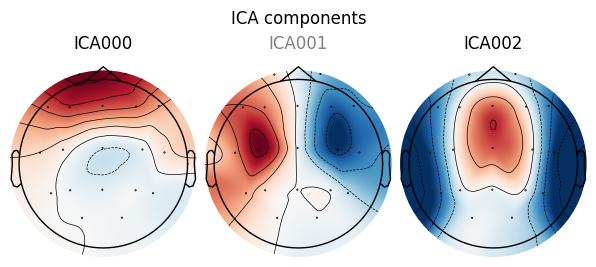

Creating RawArray with float64 data, n_channels=2, n_times=1191500
    Range : 0 ... 1191499 =      0.000 ...  2382.998 secs
Ready.


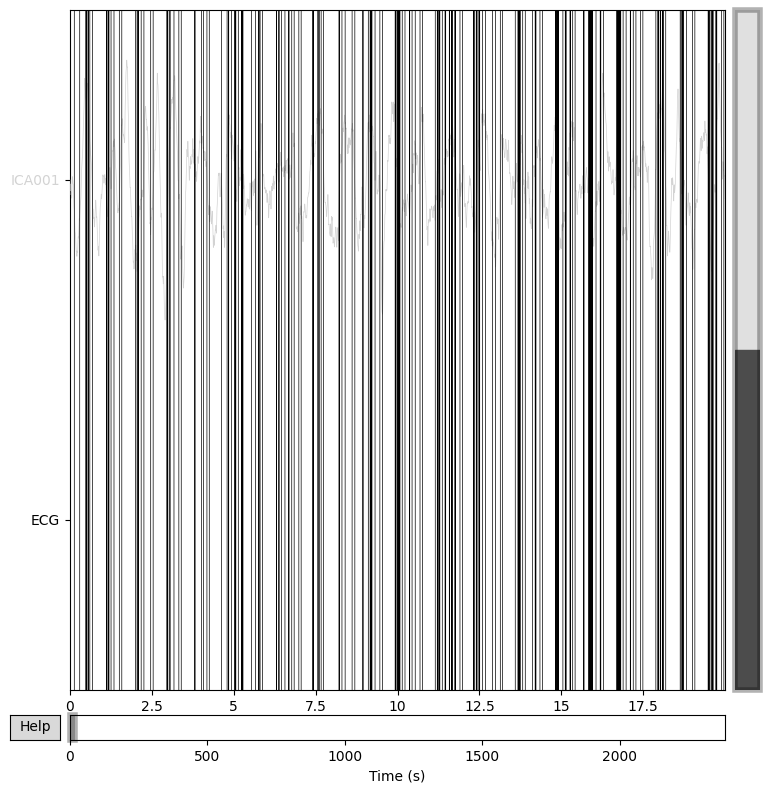

Applying ICA to Raw instance
    Transforming to ICA space (3 components)
    Zeroing out 1 ICA component
    Projecting back using 19 PCA components


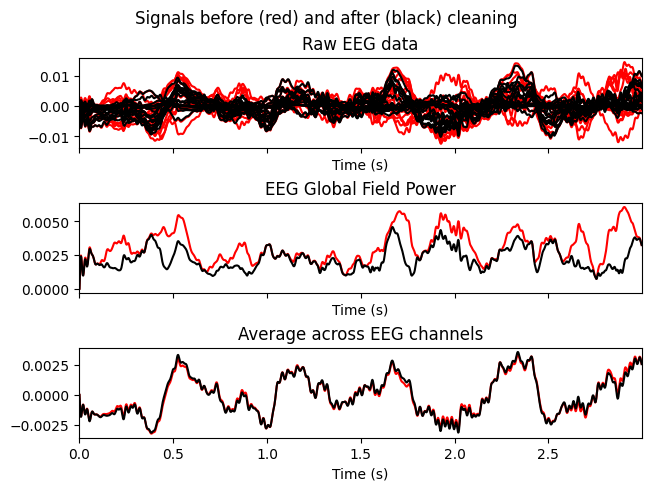

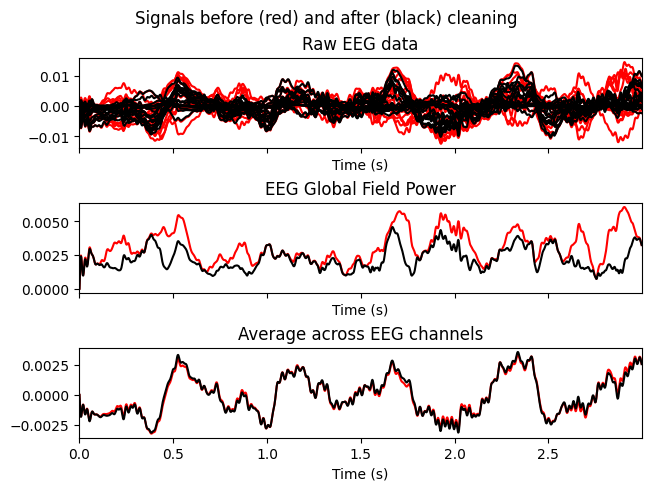

In [23]:
ica.plot_components()       # Ver tomografías
ica.plot_sources(raw_combinado, picks=[manual_ecg])  # Ver componente forzado
ica.plot_overlay(raw_combinado, exclude=[manual_ecg])  # Ver cambio visual en la señal

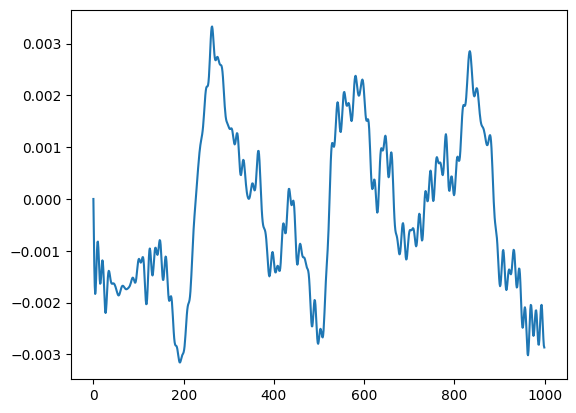

In [24]:
plt.plot(np.mean(data_clean.T[:1000],axis=1))
plt.show()

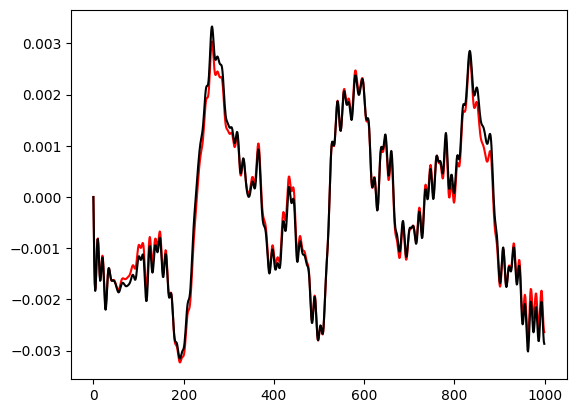

In [25]:
plt.plot(np.mean(data_orig.T[:1000],axis=1),c="red")
plt.plot(np.mean(data_clean.T[:1000],axis=1),c="black")
plt.show()

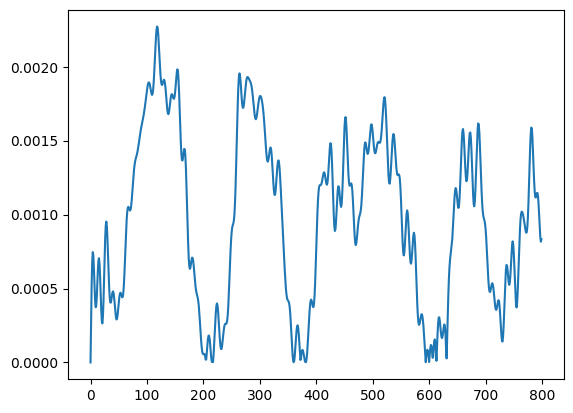

In [22]:
plt.plot(np.mean(np.abs(data_clean.T[:800]-data_orig.T[:800]),axis=1))
plt.show()

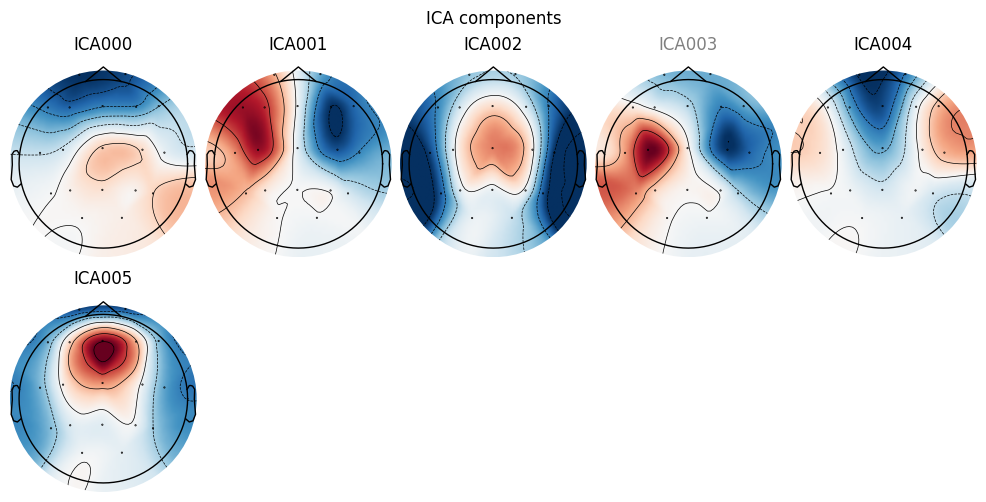

Creating RawArray with float64 data, n_channels=2, n_times=1191500
    Range : 0 ... 1191499 =      0.000 ...  2382.998 secs
Ready.
Using matplotlib as 2D backend.


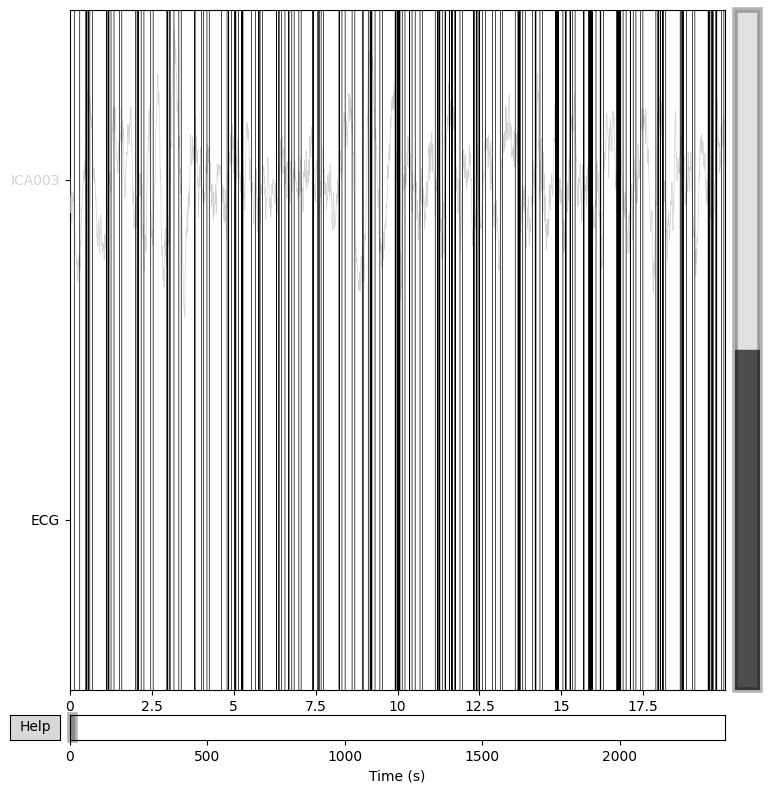

Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 1 ICA component
    Projecting back using 19 PCA components


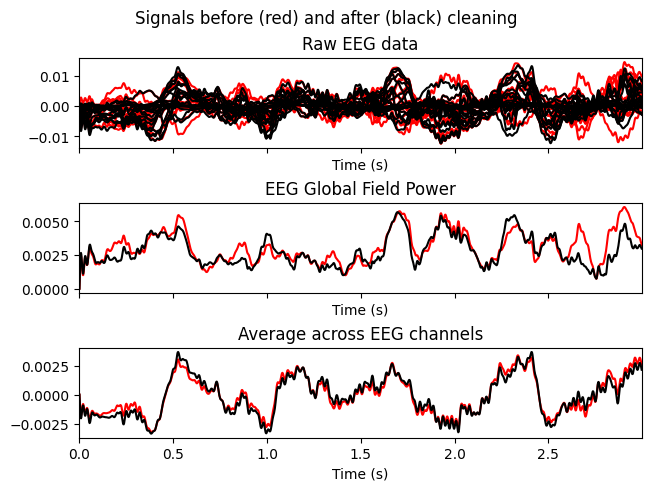

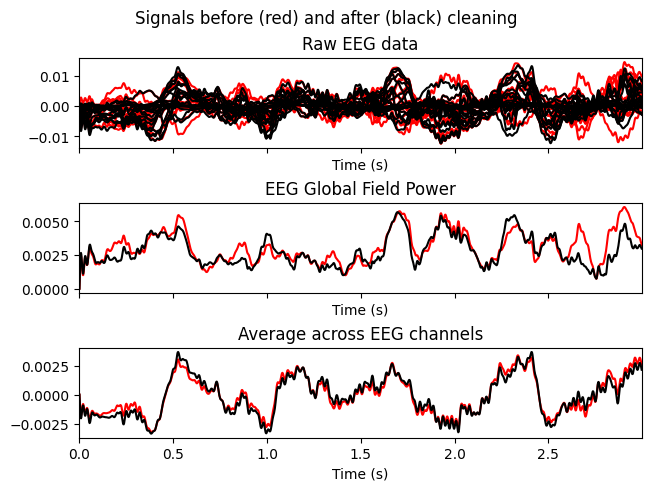

In [19]:
ica.plot_components()       # Ver tomografías
ica.plot_sources(raw_combinado, picks=[manual_ecg])  # Ver componente forzado
ica.plot_overlay(raw_combinado, exclude=[manual_ecg])  # Ver cambio visual en la señal


In [130]:
# --- 6. Visualiza la señal limpia ---
signal_by_channels(raw_eeg_limpio, "../Image/clean_eeg_signal.png")


In [131]:

# def comparar_raws_channel_por_channel(raw1, raw2, picks='eeg', start=0.0, duration=5.0, filename='comparacion_eeg.png'):
#     import matplotlib.pyplot as plt

#     raw1 = raw1.copy().pick(picks)
#     raw2 = raw2.copy().pick(picks)

#     sfreq = raw1.info['sfreq']
#     start_sample = int(start * sfreq)
#     stop_sample = int((start + duration) * sfreq)

#     data1, times = raw1[:, start_sample:stop_sample]
#     data2, _ = raw2[:, start_sample:stop_sample]
#     ch_names = raw1.ch_names

#     n_channels = len(ch_names)
#     fig, axes = plt.subplots(n_channels, 1, figsize=(12, 1.5 * n_channels), sharex=True)

#     if n_channels == 1:
#         axes = [axes]

#     for i, ax in enumerate(axes):
#         ax.plot(times, data1[i], label='Original', color='gray', alpha=0.7)
#         ax.plot(times, data2[i], label='Limpia ICA', color='blue')
#         ax.set_ylabel(ch_names[i])
#         ax.grid(True)
#         if i == 0:
#             ax.legend(loc='upper right')

#     axes[-1].set_xlabel('Tiempo (s)')
#     plt.tight_layout()
#     plt.savefig(filename)
#     plt.close(fig)

def comparar_raws_channel_por_channel(raw1, raw2, picks='eeg', start=0.0, duration=5.0, filename='../Image/comparacion_eeg.png'):
    import matplotlib.pyplot as plt

    raw1 = raw1.copy().pick(picks)
    raw2 = raw2.copy().pick(picks)

    sfreq = raw1.info['sfreq']
    start_sample = int(start * sfreq)
    stop_sample = int((start + duration) * sfreq)

    data1, times = raw1[:, start_sample:stop_sample]
    data2, _ = raw2[:, start_sample:stop_sample]
    ch_names = raw1.ch_names

    n_channels = len(ch_names)
    fig, axes = plt.subplots(n_channels, 1, figsize=(12, 1.5 * n_channels), sharex=True)

    if n_channels == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        print(f'Canal: {ch_names[i]}')  # Puedes comentar esta línea luego
        print(f'Original min/max: {data1[i].min():.6f} / {data1[i].max():.6f}')
        print(f'Limpia min/max: {data2[i].min():.6f} / {data2[i].max():.6f}')
        
        ax.plot(times, data1[i], label='Original', color='red', alpha=1.0)
        ax.plot(times, data2[i], label='Limpia ICA', color='blue')
        ax.set_ylabel(ch_names[i])
        ax.grid(True)

        # Ajustar límites Y para que ambas señales se vean bien
        ymin = min(data1[i].min(), data2[i].min()) * 1.1
        ymax = max(data1[i].max(), data2[i].max()) * 1.1
        if ymin == ymax:
            # En caso de señal plana, dar un rango pequeño
            ymin -= 0.001
            ymax += 0.001
        ax.set_ylim(ymin, ymax)

        if i == 0:
            ax.legend(loc='upper right')

    axes[-1].set_xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close(fig)


In [132]:
print("Canales en original:", filtered_signal_eeg.ch_names)
print("Canales en limpio:", raw_eeg_limpio.ch_names)



Canales en original: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
Canales en limpio: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']


In [133]:
comparar_raws_channel_por_channel(filtered_signal_eeg, raw_eeg_limpio, picks='eeg', start=10, duration=5)


Canal: Fp1
Original min/max: -0.009038 / 0.011882
Limpia min/max: -0.009127 / 0.011943
Canal: Fp2
Original min/max: -0.010720 / 0.012591
Limpia min/max: -0.010478 / 0.012751
Canal: F3
Original min/max: -0.006012 / 0.008120
Limpia min/max: -0.007052 / 0.008265
Canal: F4
Original min/max: -0.010476 / 0.011534
Limpia min/max: -0.012563 / 0.012151
Canal: C3
Original min/max: -0.006673 / 0.007260
Limpia min/max: -0.009195 / 0.009514
Canal: C4
Original min/max: -0.007778 / 0.006944
Limpia min/max: -0.009949 / 0.009080
Canal: P3
Original min/max: -0.001719 / 0.001874
Limpia min/max: -0.001536 / 0.002100
Canal: P4
Original min/max: -0.000777 / 0.000625
Limpia min/max: -0.000648 / 0.000642
Canal: O1
Original min/max: -0.000643 / 0.000791
Limpia min/max: -0.000673 / 0.000751
Canal: O2
Original min/max: -0.002117 / 0.001702
Limpia min/max: -0.002098 / 0.001717
Canal: F7
Original min/max: -0.006415 / 0.006382
Limpia min/max: -0.007909 / 0.007424
Canal: F8
Original min/max: -0.011271 / 0.010332
Lim

In [139]:
data = raw_eeg_limpio.get_data(picks='eeg')
data_flat = data[-3, :]  # Use Cz or any representative channel
fs = raw_eeg_limpio.info['sfreq']

In [ ]:
###############################################################################
### some other dependencies/codes

import mne
from mne.datasets import fetch_fsaverage
from mne.minimum_norm import make_inverse_operator, apply_inverse_raw
from mne import read_labels_from_annot
import numpy as np
from scipy.signal import welch
from scipy.stats import zscore
from scipy.spatial.distance import cosine
from scipy.signal import butter, filtfilt

def detect_rpp(data, fs, win_sec=4, step_sec=2, amp_thresh=2, entropy_thresh=0.7, freq_band=(0.5, 7)):
    def spectral_entropy(sig, fs):
        f, Pxx = welch(sig, fs)
        Pxx /= np.sum(Pxx)
        return -np.sum(Pxx * np.log2(Pxx + np.finfo(float).eps))

    win = int(win_sec * fs)
    step = int(step_sec * fs)
    rpp_epochs = []

    rms_bg = np.sqrt(np.mean(data**2))
    for start in range(0, len(data) - win, step):
        segment = data[start:start + win]
        amp = np.sqrt(np.mean(segment**2))
        se = spectral_entropy(segment, fs)
        f, Pxx = welch(segment, fs)
        dom_freq = f[np.argmax(Pxx)]
        if amp > amp_thresh * rms_bg and se < entropy_thresh and freq_band[0] <= dom_freq <= freq_band[1]:
            rpp_epochs.append((start, start + win))

    return merge_epochs(rpp_epochs, step)


def merge_epochs(epochs, step):
    if not epochs:
        return []
    merged = [epochs[0]]
    for current in epochs[1:]:
        if current[0] <= merged[-1][1] + step:
            merged[-1] = (merged[-1][0], max(merged[-1][1], current[1]))
        else:
            merged.append(current)
    return merged


def compute_bci_star(data, fs, win_sec=1, step_sec=0.5, thresh_factor=0.2):
    win = int(win_sec * fs)
    step = int(step_sec * fs)
    thresh = thresh_factor * np.std(data)
    continuity = []
    for start in range(0, len(data) - win, step):
        segment = data[start:start + win]
        continuity.append(np.std(segment) > thresh)
    return np.mean(continuity)


def compute_relative_discharge_power(data, fs, rpp_epochs, band=(1, 30)):
    total_power = bandpower(data, fs, band)
    rpp_power = sum(bandpower(data[start:end], fs, band) for start, end in rpp_epochs)
    return rpp_power / total_power if total_power > 0 else 0


def bandpower(data, fs, band):
    f, Pxx = welch(data, fs)
    idx_band = np.logical_and(f >= band[0], f <= band[1])
    return np.sum(Pxx[idx_band])


def compute_discharge_frequency(data, fs, rpp_epochs):
    total_duration = sum((end - start) for start, end in rpp_epochs) / fs
    total_zero_crossings = 0
    for start, end in rpp_epochs:
        segment = data[start:end]
        zero_crossings = np.sum(np.diff(np.sign(segment)) != 0)
        total_zero_crossings += zero_crossings
    return (total_zero_crossings / 2) / total_duration if total_duration > 0 else 0


def compute_shape_similarity(data, fs, rpp_epochs):
    segments = [zscore(data[start:end]) for start, end in rpp_epochs if end - start > 1]
    similarities = []
    for i in range(len(segments)):
        for j in range(i + 1, len(segments)):
            min_len = min(len(segments[i]), len(segments[j]))
            sim = 1 - cosine(segments[i][:min_len], segments[j][:min_len])
            similarities.append(sim)
    return np.mean(similarities) if similarities else 0


def artifact_detection(eeg, fs, amplitude_thresh=500):
    """
    Simple artifact detection: excludes channels with large signal excursions.
    eeg: samples x channels
    returns: binary array of excluded channels (1 = exclude)
    """
    return np.any(np.abs(eeg) > amplitude_thresh, axis=0).astype(int)


def calculate_qeeg_features(eeg, fs):
    """
    Compute Background Continuity Index (BCI) and
    Burst Suppression Amplitude Ratio (BSAR) per Ruijter et al. 2018.
    """
    # --- Parameters
    cutoff_value = 10  # microvolt threshold for suppression
    min_supp_duration = 0.5  # seconds
    min_burst_duration = 0.2  # seconds
    bsar_lim = [0.01, 0.99]
    min_channels = 12

    n_samples, n_channels = eeg.shape
    excl_channel = artifact_detection(eeg, fs)

    if np.sum(~excl_channel) < min_channels:
        return np.nan, np.nan

    eeg = eeg[:, ~excl_channel]

    # Bandpass filter
    b, a = butter(3, [0.5, 30], btype='bandpass', fs=fs)
    eeg = filtfilt(b, a, eeg, axis=0)

    eeg_supp = np.zeros_like(eeg, dtype=int)

    for ch in range(eeg.shape[1]):
        ch_data = eeg[:, ch]
        low_amp = np.abs(ch_data) < (cutoff_value / 2)
        suppress = np.zeros_like(ch_data, dtype=int)

        # Detect suppressions
        padded = np.concatenate([[0], low_amp.astype(int), [0]])
        starts = np.where(np.diff(padded) == 1)[0]
        ends = np.where(np.diff(padded) == -1)[0] - 1

        for s, e in zip(starts, ends):
            if e - s + 1 >= int(min_supp_duration * fs):
                suppress[s:e + 1] = 1

        # Remove short bursts
        padded2 = np.concatenate([[1], suppress, [1]])
        burst_starts = np.where(np.diff(padded2) == -1)[0]
        burst_ends = np.where(np.diff(padded2) == 1)[0] - 1

        for s, e in zip(burst_starts, burst_ends):
            if e - s + 1 < int(min_burst_duration * fs):
                suppress[s:e + 1] = 1

        eeg_supp[:, ch] = suppress

    # Remove filter edges
    eeg = eeg[fs:-fs, :]
    eeg_supp = eeg_supp[fs:-fs, :]

    bci_all = []
    bsar_all = []

    for ch in range(eeg.shape[1]):
        signal = eeg[:, ch]
        suppress = eeg_supp[:, ch]

        bci = 1 - np.mean(suppress)
        bci_all.append(bci)

        if bsar_lim[0] <= bci <= bsar_lim[1]:
            burst_amp = np.std(signal[suppress == 0])
            supp_amp = np.std(signal[suppress == 1]) if np.any(suppress) else 1
            bsar = burst_amp / supp_amp if supp_amp != 0 else 1
        else:
            bsar = 1

        bsar_all.append(bsar)

    return np.mean(bci_all), np.mean(bsar_all)



In [79]:
# run continuity and absence of periodic activity code
# Compute metrics
bci_star = compute_bci_star(data_flat, fs)
rpp_epochs = detect_rpp(data_flat, fs)
print(f"BCI*: {bci_star:.2f}, RPPs detected: {len(rpp_epochs)}")

# === CONDITIONAL EXECUTION ===
if bci_star > 0.5 and len(rpp_epochs) == 0:
    print("✓ Conditions met: proceeding to source reconstruction...")
    # >>> Continue with Step 3: fsaverage, BEM, forward model, etc.
else:
    print("✘ Skipped: insufficient continuity or RPPs present")

BCI*: 1.00, RPPs detected: 0
✓ Conditions met: proceeding to source reconstruction...


In [80]:
# === Verificar y descargar fsaverage solo si no está ===
fs_dir = fetch_fsaverage(verbose=False)  # No imprime progreso
subjects_dir = os.path.dirname(fs_dir)
subject = 'fsaverage'

# === Validar que las superficies necesarias existen ===
surf_path = os.path.join(subjects_dir, subject, 'surf')
lh_white = os.path.join(surf_path, 'lh.white')
rh_white = os.path.join(surf_path, 'rh.white')

# Verificación manual de existencia de superficies
if not os.path.isfile(lh_white) or not os.path.isfile(rh_white):
    raise FileNotFoundError("❌ Faltan archivos de superficie cortical (lh.white/rh.white). Puede que la descarga de fsaverage haya fallado.")
else:
    print("✅ fsaverage está disponible y correctamente configurado.")

✅ fsaverage está disponible y correctamente configurado.


In [81]:
# === Step 6: Source space & BEM ===
src = mne.setup_source_space(subject, spacing='oct6',
                             subjects_dir=subjects_dir, add_dist=False)

# bem_model = mne.make_bem_model(subject=subject, ico=4,
#                                 conductivity=(0.3,), subjects_dir=subjects_dir)
# bem = mne.make_bem_solution(bem_model)

bem_model = mne.make_bem_model(subject=subject, ico=4,
                              conductivity=(0.3, 0.006, 0.3), 
                              subjects_dir=subjects_dir)
bem = mne.make_bem_solution(bem_model)


Setting up the source space with the following parameters:

SUBJECTS_DIR = /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data
Subject      = fsaverage
Surface      = white
Octahedron subdivision grade 6

>>> 1. Creating the source space...

Doing the octahedral vertex picking...
Loading /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.white...
Mapping lh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 4098/163842 selected to source space (oct = 6)

Loading /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.white...
Mapping rh fsaverage -> oct (6) ...
    Triangle neighbors and vertex normals...
Loading geometry from /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/surf/rh.sphere...
Setting up the triangulation for the decimated surface...
loaded rh.white 4098/163

In [82]:
# === Step 7: Forward model ===
# --- 1. Aplicar montaje estándar 10-20 a EEG ---
# Crear el montaje estándar 10-20
montaje = mne.channels.make_standard_montage('standard_1020')
raw_con_montaje = raw_eeg_limpio.copy().set_montage(montaje)

trans = 'fsaverage'
fwd = mne.make_forward_solution(raw_con_montaje.info, trans=trans, src=src, bem=bem,
                                eeg=True, meg=False, mindist=5.0)

Source space          : <SourceSpaces: [<surface (lh), n_vertices=163842, n_used=4098>, <surface (rh), n_vertices=163842, n_used=4098>] MRI (surface RAS) coords, subject 'fsaverage', ~25.3 MiB>
MRI -> head transform : /home/nuvu-pc-nk5a/Universidad/MEG/meg_env/lib/python3.12/site-packages/mne/data/fsaverage/fsaverage-trans.fif
Measurement data      : instance of Info
Conductor model   : instance of ConductorModel
Accurate field computations
Do computations in head coordinates
Free source orientations

Read 2 source spaces a total of 8196 active source locations

Coordinate transformation: MRI (surface RAS) -> head
    0.999994 0.003552 0.000202      -1.76 mm
    -0.003558 0.998389 0.056626      31.09 mm
    -0.000001 -0.056626 0.998395      39.60 mm
    0.000000 0.000000 0.000000       1.00

Read  19 EEG channels from info
Head coordinate coil definitions created.
Source spaces are now in head coordinates.

Employing the head->MRI coordinate transform with the BEM model.
BEM model inst

In [83]:
# Aplicar referencia promedio con proyección (OBLIGATORIO para EEG)
raw_con_montaje.set_eeg_reference('average', projection=True)
# # === Step 6: Noise covariance ===
noise_cov = mne.compute_raw_covariance(raw_con_montaje, tmin=0, tmax=None)

# # === Step 7: Crear inverse operator (sin método) ===
inverse_operator = make_inverse_operator(raw_con_montaje.info, fwd, noise_cov,
                                          loose=0.2, depth=0.8)

# # === Step 8: Aplicar eLORETA para obtener la estimación de fuentes ===
# snr = 3.0
# lambda2 = 1.0 / snr**2

# stc = apply_inverse_raw(raw_con_montaje, inverse_operator, lambda2=lambda2,
#                         method='eLORETA', start=0, stop=None, pick_ori=None)

sfreq = raw_con_montaje.info['sfreq']  # frecuencia de muestreo
start = 0
stop = int(sfreq * 30)  # primeros 60 segundos

snr = 3.0
lambda2 = 1.0 / snr**2

stc_fragment = apply_inverse_raw(raw_con_montaje, inverse_operator, lambda2=lambda2,
                                method='eLORETA', start=start, stop=stop,
                                buffer_size=1000, pick_ori=None)





EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Using up to 11915 segments
Number of samples used : 1191500
[done]
Converting forward solution to surface orientation
    No patch info available. The standard source space normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Computing inverse operator with 19 channels.
    19 out of 19 channels remain after picking
Selected 19 channels
Creating the depth weighting matrix...
    19 EEG channels
    limit = 8197/8196 = 2.466933
    scale = 41987 exp = 0.8
Applying loose dipole orientations to surface source spaces: 0.2
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 1)
Computing rank from covariance with rank=None
    Using tolerance 2.1e-09 

In [84]:
# Paso 1: cargar etiquetas del atlas
labels = read_labels_from_annot(subject='fsaverage', parc='aparc.a2009s',
                                subjects_dir=subjects_dir)

# Índices de las regiones que quieres extraer (Gong 2009 en este caso)
gong_indices = np.array([
    27,21,5,25,9,15,3,7,11,13,23,19,69,1,17,57,59,61,63,65,67,49,51,53,
    43,45,47,55,79,81,85,89,83,87,39,31,33,35,29,28,22,6,26,10,16,4,8,
    12,14,24,20,70,2,18,58,60,62,64,66,68,50,52,54,44,46,48,56,80,82,86,
    90,84,88,40,32,34,36,30
]) - 1

# Paso 2: extraer las etiquetas Gong
gong_labels = [labels[i] for i in gong_indices if i < len(labels)]

# Paso 3: crear el arreglo para almacenar señales (regiones x tiempo)
n_regions = len(gong_labels)
n_times = len(stc_fragment.times)
virtual_electrodes = np.zeros((n_regions, n_times))

# Paso 4: extraer promedio de actividad para cada región
for i, label in enumerate(gong_labels):
    stc_label = stc_fragment.in_label(label)              # extrae fuentes dentro de la región
    virtual_electrodes[i, :] = stc_label.data.mean(axis=0)  # promedio espacial en la región


Reading labels from parcellation...
   read 75 labels from /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/label/lh.aparc.a2009s.annot
   read 75 labels from /home/nuvu-pc-nk5a/mne_data/MNE-fsaverage-data/fsaverage/label/rh.aparc.a2009s.annot


In [85]:
virtual_electrodes.shape

(78, 15000)

In [86]:
import scipy.io
def save_array_as_mat(array, ruta_archivo, nombre_variable):

    if not isinstance(array, np.ndarray):
        raise TypeError("El argumento 'array' debe ser un numpy.ndarray")
    
    try:
        # Guardamos el array con el nombre de variable dado
        scipy.io.savemat(ruta_archivo, {nombre_variable: array})
        print(f"Archivo guardado correctamente en: {ruta_archivo}")
    except Exception as e:
        print(f"Error al guardar el archivo .mat: {e}")

In [87]:
save_array_as_mat(virtual_electrodes, "matrix_poc.mat", "data")

Archivo guardado correctamente en: matrix_poc.mat
